# Music Sheet Symbol Detector

OMR pipeline on DeepScoresV2: preprocessing, staff removal, notehead segmentation and evaluation.

In [1]:
import os, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

## 1. Dataset

DeepScoresV2 dense split - 1362 images, 135 classes, annotations in COCO-like JSON format.

In [2]:
# run once to download
# import requests
# from tqdm import tqdm
# import tarfile
#
# def download_file(url, dest):
#     os.makedirs(os.path.dirname(dest), exist_ok=True)
#     r = requests.get(url, stream=True)
#     total = int(r.headers.get('content-length', 0))
#     with open(dest, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=dest) as bar:
#         for chunk in r.iter_content(8192):
#             f.write(chunk)
#             bar.update(len(chunk))
#
# download_file("https://zenodo.org/records/4012193/files/ds2_dense.tar.gz", "data/ds2_dense.tar.gz")
# with tarfile.open("data/ds2_dense.tar.gz", "r:gz") as tar:
#     tar.extractall("data/", filter='data')

In [3]:
with open("data/ds2_dense/deepscores_train.json") as f:
    data = json.load(f)

# keep only deepscores annotation set (ids 1-136)
categories = {k: v for k, v in data['categories'].items() if v['annotation_set'] == 'deepscores'}
id_to_name = {k: v['name'] for k, v in categories.items()}

anns_by_img = {}
for ann_id, ann in data['annotations'].items():
    img_id = ann['img_id']
    anns_by_img.setdefault(img_id, []).append(ann)

print(f"{len(categories)} classes, {len(anns_by_img)} images")

136 classes, 1362 images


## 2. Preprocessing

Load a sample image, binarize with Otsu, then remove staff lines and barlines using morphological operations.

In [4]:
sample_img_info = data['images'][0]
img = cv2.imread(f"data/ds2_dense/images/{sample_img_info['filename']}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_id = str(sample_img_info['id'])
sample_anns = anns_by_img.get(img_id, [])

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

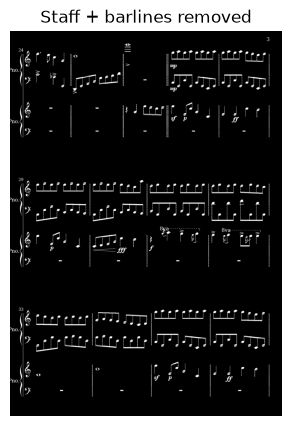

In [5]:
h_img, w_img = img_bin.shape

# staff lines: long horizontal structures
kernel_horiz = cv2.getStructuringElement(cv2.MORPH_RECT, (w_img // 4, 1))
staff = cv2.dilate(cv2.erode(img_bin, kernel_horiz), kernel_horiz)
img_no_staff = cv2.subtract(img_bin, staff)

# barlines: tall vertical structures
kernel_vert = cv2.getStructuringElement(cv2.MORPH_RECT, (1, h_img // 20))
bars = cv2.dilate(cv2.erode(img_no_staff, kernel_vert), kernel_vert)
img_clean = cv2.subtract(img_no_staff, bars)

plt.figure(figsize=(14, 5))
plt.imshow(img_clean, cmap='gray')
plt.title("Staff + barlines removed")
plt.axis('off')
plt.show()

## 3. Segmentation

Connected components on the cleaned image. We filter by size and aspect ratio to keep notehead-shaped blobs.

In [6]:
# ground truth noteheads
notehead_cats = {'noteheadBlackOnLine', 'noteheadBlackInSpace',
                 'noteheadWholeOnLine', 'noteheadWholeInSpace',
                 'noteheadHalfOnLine', 'noteheadHalfInSpace'}

gt_noteheads = []
for ann in sample_anns:
    if id_to_name.get(ann['cat_id'][0], '?') in notehead_cats:
        x1, y1, x2, y2 = ann['a_bbox']
        gt_noteheads.append((int(x1), int(y1), int(x2), int(y2)))

avg_w = np.mean([x2 - x1 for (x1, y1, x2, y2) in gt_noteheads])
avg_h = np.mean([y2 - y1 for (x1, y1, x2, y2) in gt_noteheads])
print(f"GT noteheads: {len(gt_noteheads)}, avg size: {avg_w:.1f} x {avg_h:.1f} px")

GT noteheads: 225, avg size: 19.9 x 16.7 px


In [7]:
num_labels, _, stats, _ = cv2.connectedComponentsWithStats(img_clean)

detected_noteheads = []
for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    aspect = w / h if h > 0 else 0
    if 0.5 < aspect < 2.0 and avg_w * 0.4 < w < avg_w * 2 and h < avg_h * 2 and area > 15:
        detected_noteheads.append((x, y, x + w, y + h))

print(f"Detected: {len(detected_noteheads)}")

Detected: 335


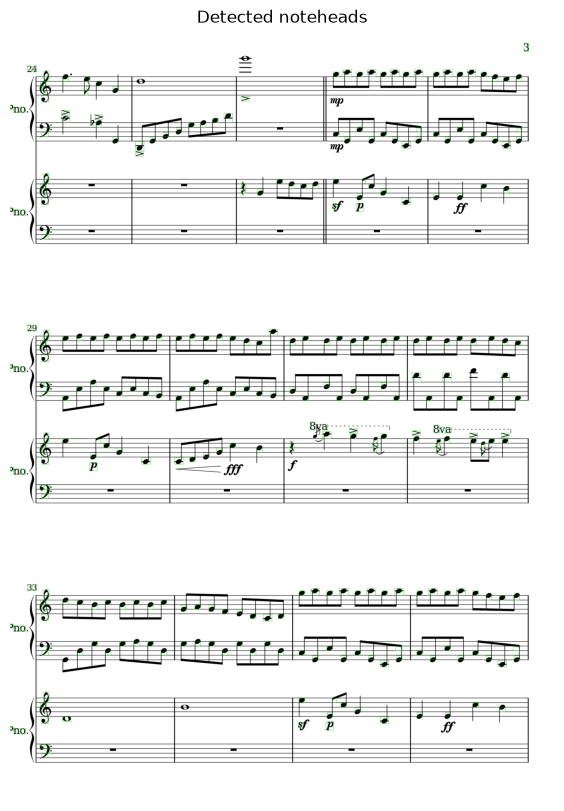

In [8]:
img_seg = img_rgb.copy()
for (x1, y1, x2, y2) in detected_noteheads:
    cv2.rectangle(img_seg, (x1, y1), (x2, y2), (0, 200, 0), 1)

plt.figure(figsize=(14, 10))
plt.imshow(img_seg)
plt.title("Detected noteheads")
plt.axis('off')
plt.show()

## 4. Evaluation


In [9]:
def center_in_box(det, gt):
    cx = (det[0] + det[2]) / 2
    cy = (det[1] + det[3]) / 2
    return gt[0] <= cx <= gt[2] and gt[1] <= cy <= gt[3]

def evaluate(detections, gt_boxes):
    tp, fp = 0, 0
    matched = set()
    for det in detections:
        hit = False
        for i, gt in enumerate(gt_boxes):
            if i not in matched and center_in_box(det, gt):
                tp += 1
                matched.add(i)
                hit = True
                break
        if not hit:
            fp += 1
    fn = len(gt_boxes) - len(matched)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return tp, fp, fn, precision, recall, f1, matched

In [10]:
tp, fp, fn, precision, recall, f1, matched = evaluate(detected_noteheads, gt_noteheads)

print(f"GT: {len(gt_noteheads)}  Detected: {len(detected_noteheads)}")
print(f"TP={tp}  FP={fp}  FN={fn}")
print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")

GT: 225  Detected: 335
TP=185  FP=150  FN=40
Precision: 0.552  Recall: 0.822  F1: 0.661


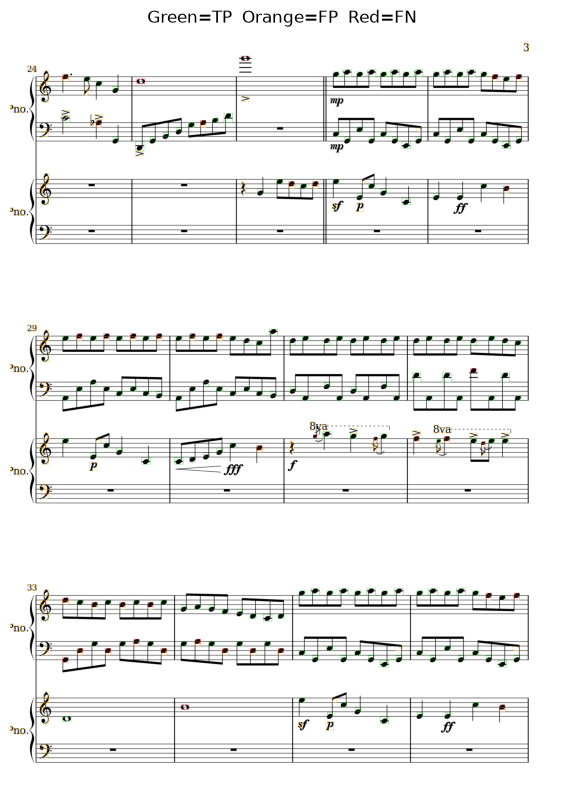

In [11]:
# visualize TP / FP / FN
img_eval = img_rgb.copy()
tp_dets = [det for det in detected_noteheads if any(center_in_box(det, gt_noteheads[i]) for i in matched)]
fp_dets = [det for det in detected_noteheads if det not in tp_dets]
fn_boxes = [gt for i, gt in enumerate(gt_noteheads) if i not in matched]

for (x1, y1, x2, y2) in tp_dets:
    cv2.rectangle(img_eval, (x1, y1), (x2, y2), (0, 200, 0), 1)
for (x1, y1, x2, y2) in fp_dets:
    cv2.rectangle(img_eval, (x1, y1), (x2, y2), (255, 165, 0), 1)
for (x1, y1, x2, y2) in fn_boxes:
    cv2.rectangle(img_eval, (x1, y1), (x2, y2), (255, 0, 0), 1)

plt.figure(figsize=(14, 10))
plt.imshow(img_eval)
plt.title("Green=TP  Orange=FP  Red=FN")
plt.axis('off')
plt.show()